In [1]:
import numpy as np
import matplotlib.pyplot as plt
import collections
import ROOT as root
import awkward as ak
import uproot
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import OPTICS

Welcome to JupyROOT 6.26/16


In [2]:
#Primary goal of this work is to evaluate the performance of DB scan on various clustering tasks, lets grab a random file and pull some events to look at.
data_merged = np.load('/sdf/data/neutrino/summer25/ktwall/tms_timing/multihit/mulithit_detector_sim_lossy_2510.npz')
merged_hit_array = data_merged['first']
def SortByTime(array):
    sorted_array = array[np.argsort(array[:,5])]
    return(sorted_array)
time_sorted_hits = SortByTime(merged_hit_array)


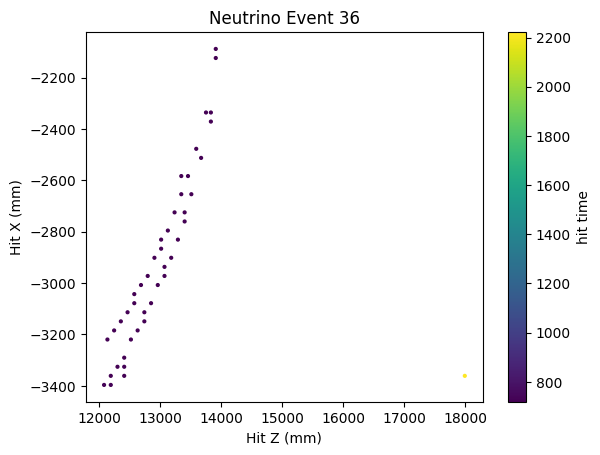

In [3]:
#Simple event display to get an idea of what exactly we are clustering
neutrino_event_number = 36
sub_array = time_sorted_hits[time_sorted_hits[:,0] == neutrino_event_number]
hit_xs = sub_array[:,2]
hit_zs = sub_array[:,4]
hit_ts = sub_array[:,5]
hit_PEs = sub_array[:,6]
plt.scatter(hit_zs, hit_xs, s = 4, c = hit_ts, cmap = 'viridis')
plt.colorbar(label = 'hit time')
plt.title(f"Neutrino Event {neutrino_event_number}")
plt.xlabel("Hit Z (mm)")
plt.ylabel("Hit X (mm)")
plt.show()

In [4]:
#Let's create our array of coordinates 
hit_vecs = []
for i in range(len(hit_xs)):
    hit_vec = [hit_zs[i], hit_xs[i], hit_ts[i]]
    hit_vecs.append(hit_vec)

hit_vec_array = np.array(hit_vecs) #this is the object we will use. 


(0.0, 500.0)

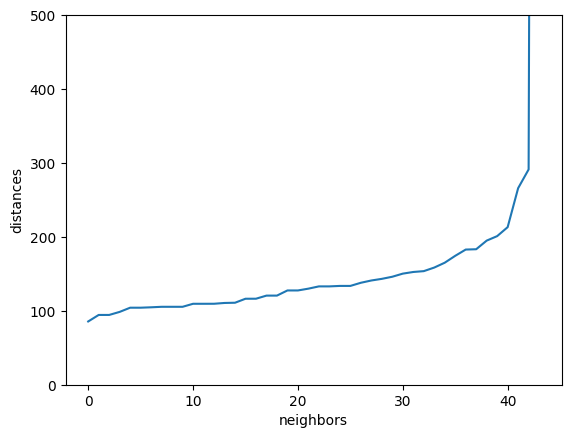

In [6]:
#basic test - DBSCAN takes eps = max distance to be considered neighbors ; min_samples = number of samples for a point to be considered a core point
#rule of thumb, should have min samples by 2*dimension of data. 
#create a kneighbors plot, grab the point of maximal curvature. 
neighbors = NearestNeighbors(n_neighbors=6)
neighbors_fit = neighbors.fit(hit_vec_array)
distances, indices = neighbors_fit.kneighbors(hit_vec_array)
distances = np.sort(distances, axis=0)
distances = np.mean(distances[:,1:],axis=1)
distances = np.sort(distances)
plt.plot(distances)
#plt.xlim((40,50))
plt.xlabel("neighbors")
plt.ylabel("distances")
plt.ylim((0,500))

In [7]:
clusters = DBSCAN(eps = 255, min_samples = 6).fit(hit_vec_array)
clusters.labels_

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0, -1, -1,  0,  0,  0,  0, -1])

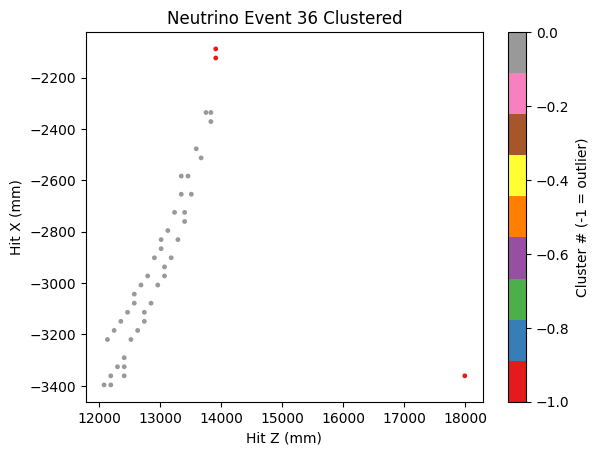

In [8]:
plt.scatter(hit_zs, hit_xs, s = 6, c = clusters.labels_, cmap = 'Set1')
plt.xlabel("Hit Z (mm)")
plt.ylabel("Hit X (mm)")
plt.colorbar(label = "Cluster # (-1 = outlier)")
plt.title(f"Neutrino Event {neutrino_event_number} Clustered")
plt.show()

In [9]:
#As expected, everything is tossed into the outlier category, did zero fine tuning of parameters! Let's take a look.
def PointDistance(vec1,vec2):
    euclid_dist = np.sqrt( (vec1[0] - vec2[0] )**2 + (vec1[1] - vec2[1] )**2 + (vec1[2] - vec2[2] )**2 )
    return(euclid_dist)

In [10]:
euclid_dist_points = []
for i, vec1 in enumerate(hit_vecs):
    if i != (len(hit_vecs) - 1):
        vec2 = hit_vecs[i+1]
        #print(PointDistance(vec1,vec2))     

In [11]:
#This is a little unsystematic, lets see if we can scan some parameter space!
eps_range = range(1,200)
min_samples_range = range(2,15)
results_list = []
for eps_ in eps_range:
    for min_samples_ in min_samples_range:
        clusters = DBSCAN(eps = eps_, min_samples = min_samples_).fit(hit_vec_array)
        labels_array = clusters.labels_
        result = [eps_, min_samples_, len(np.unique(labels_array))]
        results_list.append(result)
results_stack = np.array(results_list)

In [12]:
results_stack

array([[  1,   2,   1],
       [  1,   3,   1],
       [  1,   4,   1],
       ...,
       [199,  12,   1],
       [199,  13,   1],
       [199,  14,   1]])

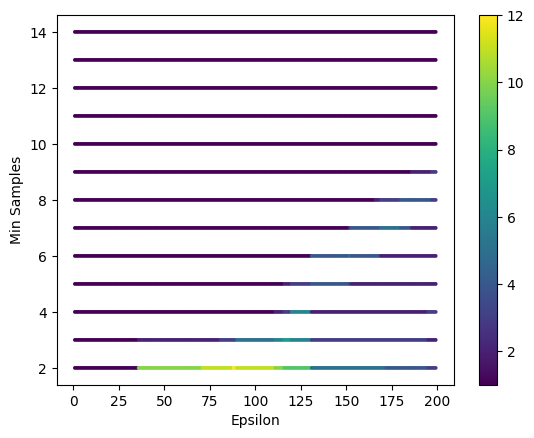

In [13]:
plt.scatter(results_stack[:,0], results_stack[:,1], c = results_stack[:,2], s = 3)
plt.xlabel("Epsilon")
plt.ylabel("Min Samples")
plt.colorbar()

In [14]:
#I want to try this out on time slices now!! See what optimizations we could make there. 
time_slice_file = uproot.open("/sdf/data/neutrino/summer25/ktwall/tms_timing/time_sliced/file_2510_sliced_init-8.0_drop-4.0.root") #grab the time slice output
time_slices = time_slice_file['Time Slices']
basic_metrics = time_slice_file['Metrics']

def UnpackRoot(time_slices):
    n_slices = time_slices.num_entries
    all_slices = []
    for i in range(n_slices): #range(n_slices):
        arrays = time_slices.arrays()[i]
        hits_in_slice = arrays['n']
        # Pull each field (these are variable-length arrays per slice)
        nns = arrays['neutrino number']
        hns = arrays['hit number']
        xs  = arrays['hit x']
        ys  = arrays['hit y']
        zs  = arrays['hit z']
        ts  = arrays['hit time']
        PEs = arrays['hit PE']
        ors = arrays['bar orientation']
    
        # Stack into a 2D array for this slice: shape (n_hits_in_slice, 8)
        horiz = np.column_stack([
            ak.to_numpy(nns),
            ak.to_numpy(hns),
            ak.to_numpy(xs),
            ak.to_numpy(ys),
            ak.to_numpy(zs),
            ak.to_numpy(ts),
            ak.to_numpy(PEs),
            ak.to_numpy(ors)
        ])
    
        all_slices.append(horiz)

    return(all_slices)

slice_list = UnpackRoot(time_slices)

Text(0, 0.5, 'Hit X (mm)')

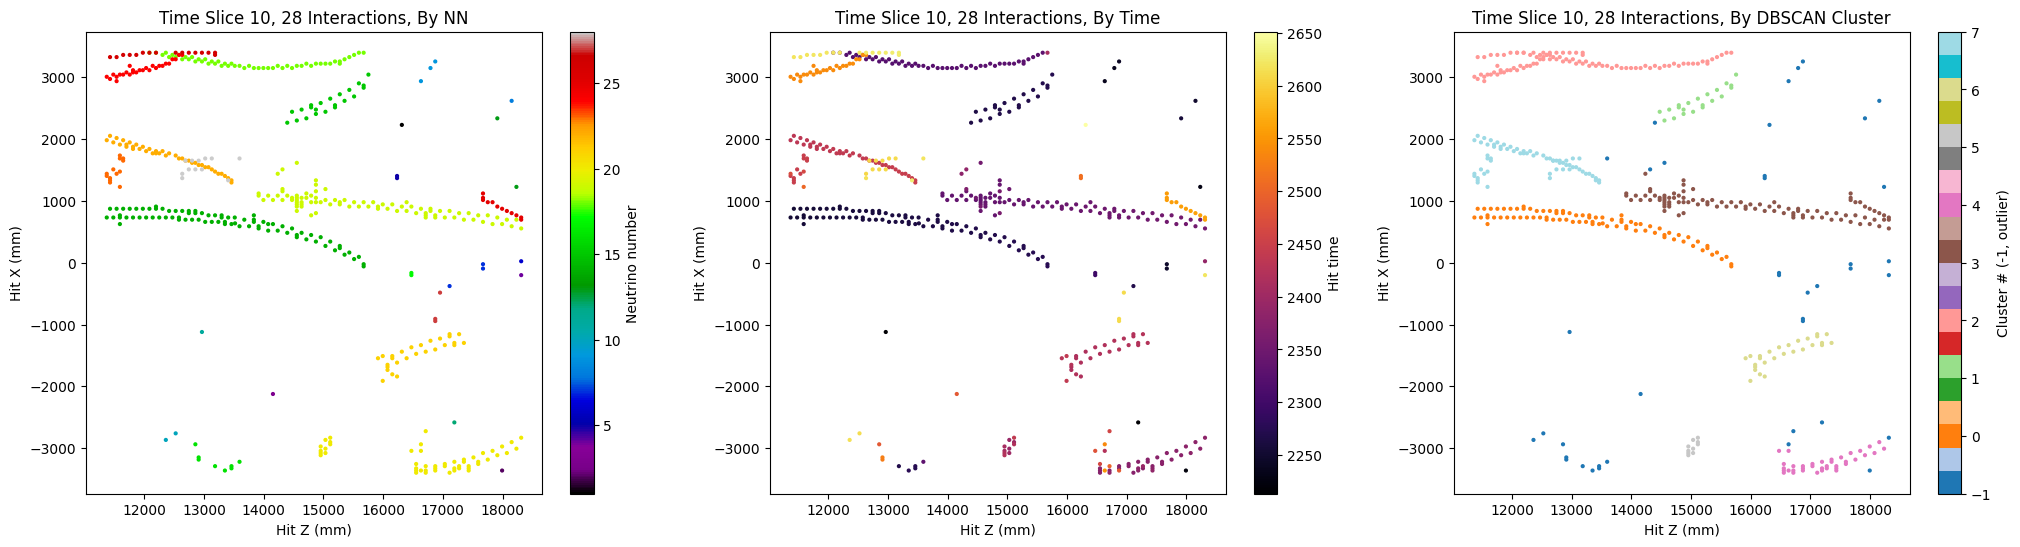

In [68]:
#Some time slicing displays
slice_number = 10
sub_array = slice_list[slice_number]
hit_xs = sub_array[:,2]
hit_zs = sub_array[:,4]
hit_ts = sub_array[:,5]
hit_PEs = sub_array[:,6]
hit_nns = sub_array[:,0]
#color corrector lol
unique_vals, inverse = np.unique(hit_nns, return_inverse=True)

# Map to 1-based index
mapped = inverse + 1
hit_nns_mapped = mapped

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(25, 6))

sc1 = ax1.scatter(hit_zs, hit_xs, s = 4, c = hit_nns_mapped , cmap = 'nipy_spectral')
fig.colorbar(sc1, ax=ax1, label = 'Neutrino number')
ax1.set_title(f"Time Slice {slice_number}, {len(np.unique(hit_nns))} Interactions, By NN")
ax1.set_xlabel("Hit Z (mm)")
ax1.set_ylabel("Hit X (mm)")

sc2 = ax2.scatter(hit_zs, hit_xs, s = 4, c = hit_ts , cmap = 'inferno')
fig.colorbar(sc2, ax=ax2, label = 'Hit time')
ax2.set_title(f"Time Slice {slice_number}, {len(np.unique(hit_nns))} Interactions, By Time")
ax2.set_xlabel("Hit Z (mm)")
ax2.set_ylabel("Hit X (mm)")

#Let's create our array of coordinates 
hit_vecs = []
for i in range(len(hit_xs)):
    hit_vec = [hit_zs[i], hit_xs[i], hit_ts[i]]
    hit_vecs.append(hit_vec)

hit_vec_array = np.array(hit_vecs) #this is the object we will use.

db_clusters = DBSCAN(eps = 280, min_samples = 6).fit(hit_vec_array)

sc3 = ax3.scatter(hit_zs, hit_xs, s = 4, c = db_clusters.labels_, cmap = 'tab20')
fig.colorbar(sc3, ax=ax3, label = 'Cluster # (-1, outlier)')
ax3.set_title(f"Time Slice {slice_number}, {len(np.unique(hit_nns))} Interactions, By DBSCAN Cluster")
ax3.set_xlabel("Hit Z (mm)")
ax3.set_ylabel("Hit X (mm)")

(0.0, 500.0)

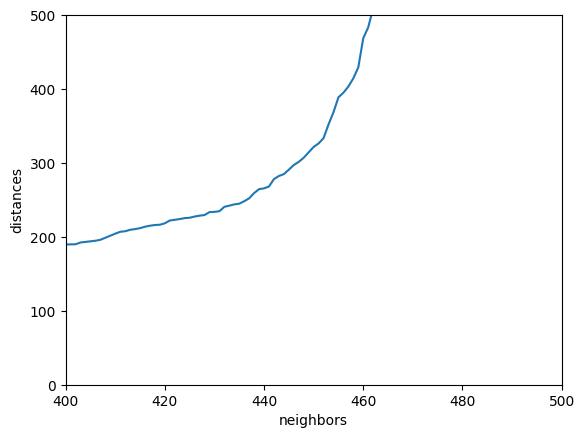

In [29]:
#Some kNN analysis, use this to tweak above values. 
neighbors = NearestNeighbors(n_neighbors=6)
neighbors_fit = neighbors.fit(hit_vec_array)
distances, indices = neighbors_fit.kneighbors(hit_vec_array)
distances = np.sort(distances, axis=0)
distances = np.mean(distances[:,1:],axis=1)
distances = np.sort(distances)
plt.plot(distances)
plt.xlim((400,500))
plt.xlabel("neighbors")
plt.ylabel("distances")
plt.ylim((0,500))

In [65]:
#Lets see if we can normalize in a sense. This should weight time and position equally. 
slice_number = 10 #10
sub_array = slice_list[slice_number]
hit_xs = sub_array[:,2]
hit_zs = sub_array[:,4]
hit_ts = sub_array[:,5]
hit_PEs = sub_array[:,6]
hit_nns = sub_array[:,0]

#Lets normalize x
min_x = min(hit_xs)
max_x = max(hit_xs)
x_range = max_x - min_x
normalized_xs = (hit_xs + abs(min_x)) / x_range

#Normalize z
min_z = min(hit_zs)
max_z = max(hit_zs)
normalized_zs = (hit_zs - min_z) / (max_z - min_z)

#Normalize t (this won't work for negative t I don't think..)
min_t = min(hit_ts)
max_t = max(hit_ts)
normalized_ts = (hit_ts - min_t) / (max_t - min_t)

norm_hit_vecs = []
for i in range(len(normalized_xs)):
    norm_hit_vec = [normalized_zs[i], normalized_xs[i], normalized_ts[i]]
    norm_hit_vecs.append(norm_hit_vec)

norm_hit_vec_array = np.array(norm_hit_vecs)

Text(0, 0.5, 'distances')

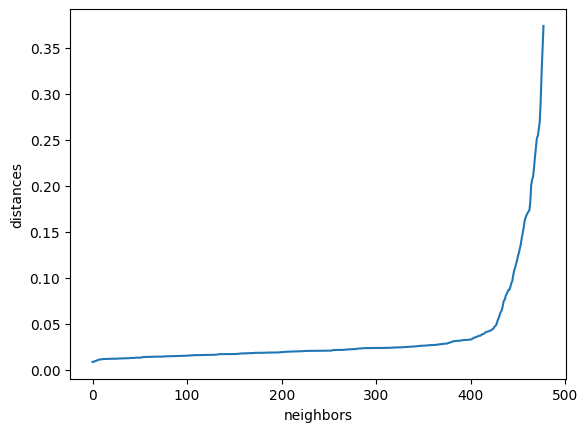

In [66]:
#Some kNN analysis, use this to tweak above values. 
neighbors = NearestNeighbors(n_neighbors=6)
neighbors_fit = neighbors.fit(norm_hit_vec_array)
distances, indices = neighbors_fit.kneighbors(norm_hit_vec_array)
distances = np.sort(distances, axis=0)
distances = np.mean(distances[:,1:],axis=1)
distances = np.sort(distances)
plt.plot(distances)
#plt.xlim((400,500))
plt.xlabel("neighbors")
plt.ylabel("distances")

Text(0, 0.5, 'Hit X (mm)')

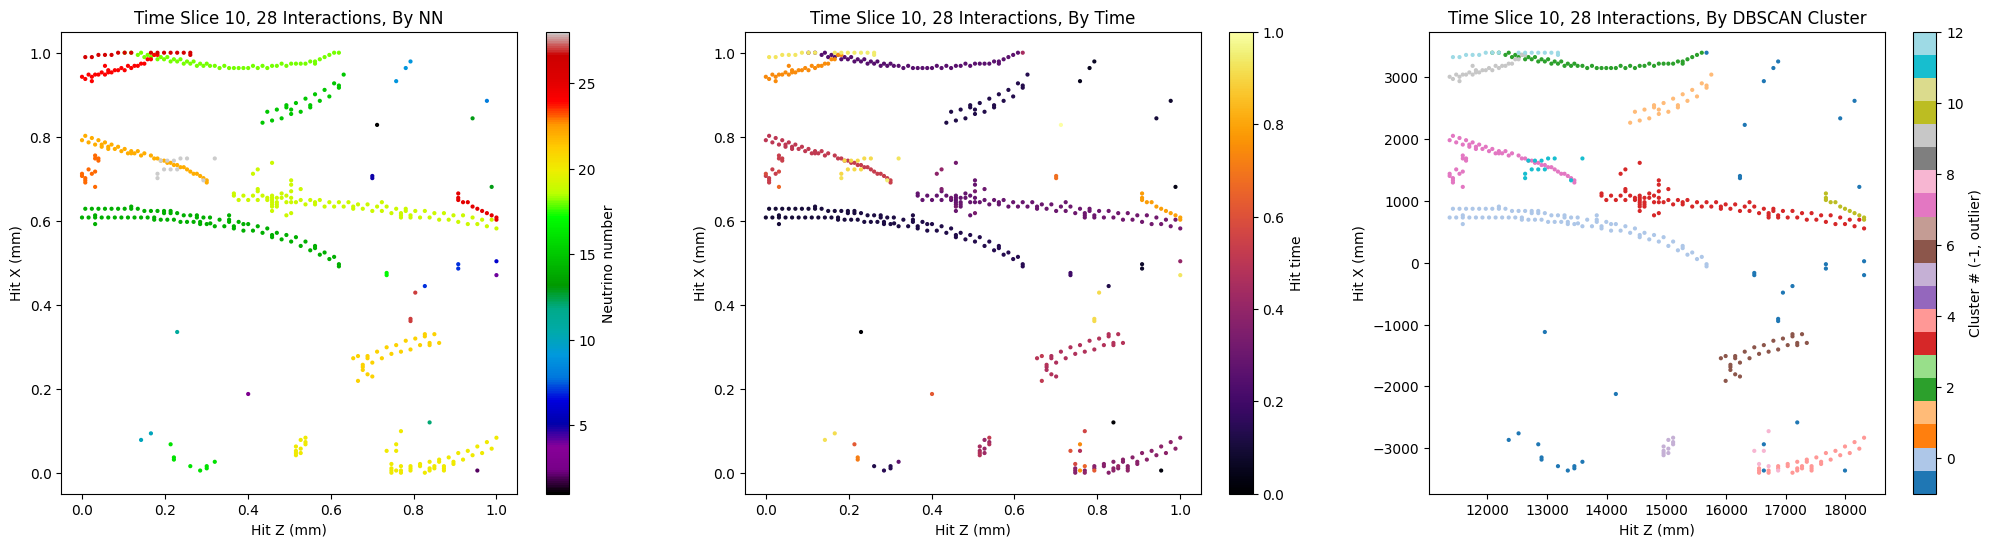

In [67]:
#Using DBSCAN

#color corrector lol
unique_vals, inverse = np.unique(hit_nns, return_inverse=True)

# Map to 1-based index
mapped = inverse + 1
hit_nns_mapped = mapped

fig, (ax1, ax2,ax3) = plt.subplots(1, 3, figsize=(25, 6))

sc1 = ax1.scatter(normalized_zs, normalized_xs, s = 4, c = hit_nns_mapped , cmap = 'nipy_spectral')
fig.colorbar(sc1, ax=ax1, label = 'Neutrino number')
ax1.set_title(f"Time Slice {slice_number}, {len(np.unique(hit_nns))} Interactions, By NN")
ax1.set_xlabel("Hit Z (mm)")
ax1.set_ylabel("Hit X (mm)")

sc2 = ax2.scatter(normalized_zs, normalized_xs, s = 4, c = normalized_ts , cmap = 'inferno')
fig.colorbar(sc2, ax=ax2, label = 'Hit time')
ax2.set_title(f"Time Slice {slice_number}, {len(np.unique(hit_nns))} Interactions, By Time")
ax2.set_xlabel("Hit Z (mm)")
ax2.set_ylabel("Hit X (mm)")

hit_vec_array = np.array(hit_vecs) #this is the object we will use.

db_clusters = DBSCAN(eps = 0.10, min_samples = 6).fit(norm_hit_vec_array)

sc3 = ax3.scatter(hit_zs, hit_xs, s = 4, c = db_clusters.labels_, cmap = 'tab20')
fig.colorbar(sc3, ax=ax3, label = 'Cluster # (-1, outlier)')
ax3.set_title(f"Time Slice {slice_number}, {len(np.unique(hit_nns))} Interactions, By DBSCAN Cluster")
ax3.set_xlabel("Hit Z (mm)")
ax3.set_ylabel("Hit X (mm)")


Text(0, 0.5, 'Hit X (mm)')

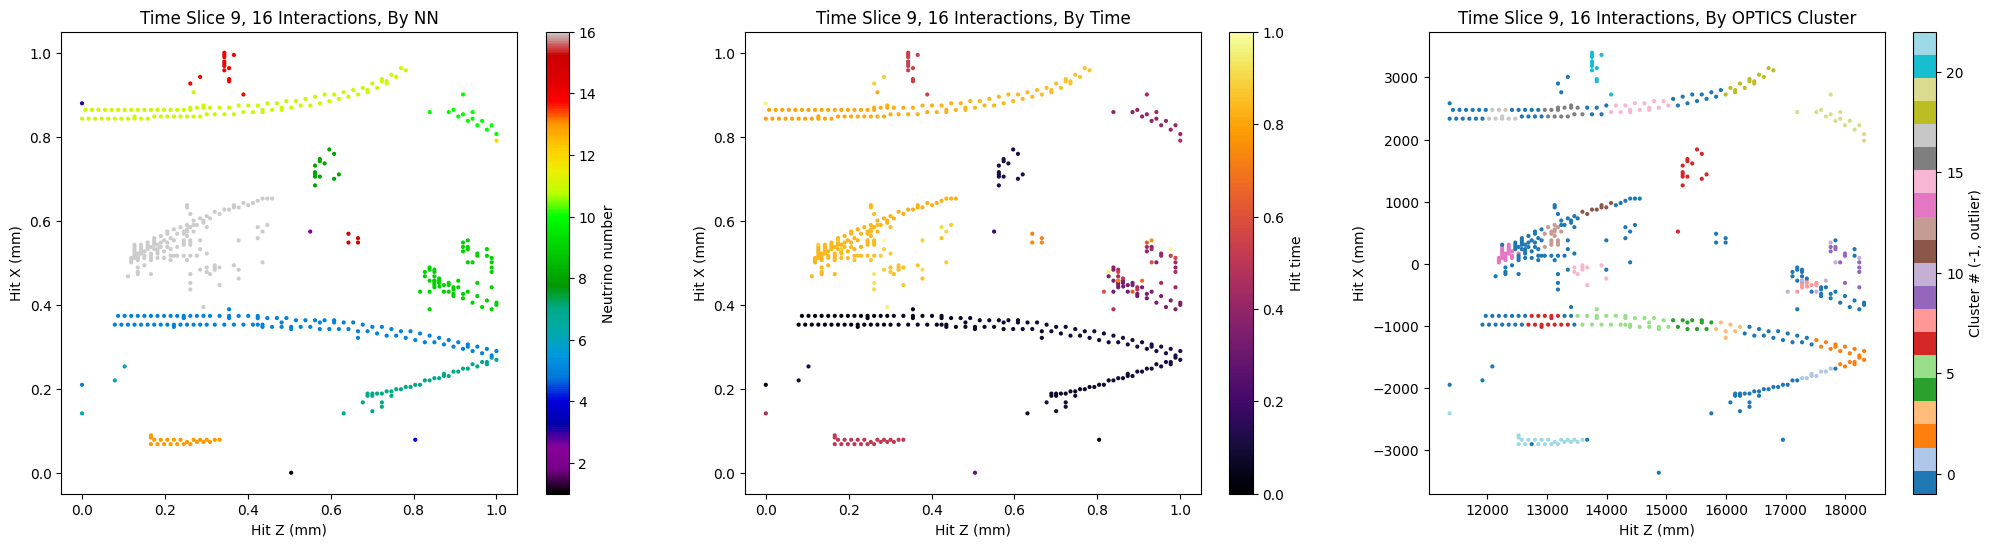

In [64]:
#Using OPTICS (no epsilon is required, just cluster points, maybe will perform better across different sorts of cluster sizes) - answer is generally no. 

#color corrector lol
unique_vals, inverse = np.unique(hit_nns, return_inverse=True)

# Map to 1-based index
mapped = inverse + 1
hit_nns_mapped = mapped

fig, (ax1, ax2,ax3) = plt.subplots(1, 3, figsize=(25, 6))

sc1 = ax1.scatter(normalized_zs, normalized_xs, s = 4, c = hit_nns_mapped , cmap = 'nipy_spectral')
fig.colorbar(sc1, ax=ax1, label = 'Neutrino number')
ax1.set_title(f"Time Slice {slice_number}, {len(np.unique(hit_nns))} Interactions, By NN")
ax1.set_xlabel("Hit Z (mm)")
ax1.set_ylabel("Hit X (mm)")

sc2 = ax2.scatter(normalized_zs, normalized_xs, s = 4, c = normalized_ts , cmap = 'inferno')
fig.colorbar(sc2, ax=ax2, label = 'Hit time')
ax2.set_title(f"Time Slice {slice_number}, {len(np.unique(hit_nns))} Interactions, By Time")
ax2.set_xlabel("Hit Z (mm)")
ax2.set_ylabel("Hit X (mm)")

hit_vec_array = np.array(hit_vecs) #this is the object we will use.

db_clusters = OPTICS(min_samples = 6).fit(norm_hit_vec_array)

sc3 = ax3.scatter(hit_zs, hit_xs, s = 4, c = db_clusters.labels_, cmap = 'tab20')
fig.colorbar(sc3, ax=ax3, label = 'Cluster # (-1, outlier)')
ax3.set_title(f"Time Slice {slice_number}, {len(np.unique(hit_nns))} Interactions, By OPTICS Cluster")
ax3.set_xlabel("Hit Z (mm)")
ax3.set_ylabel("Hit X (mm)")
